# Travel Personas

### Imports

In [26]:
import pandas as pd
import numpy as np
import scipy as sp
import plotly.express as px
import plotly.graph_objects as go
import datetime

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

### Variables

In [48]:
transport_types = {
    'hitchhiking': {
        'values': ['hitchhiking'],
        'comfort_mapping': 1
    },
    'self': {
        'values': ['car', 'car share'],
        'comfort_mapping': 5
    },
    'bus': {
        'values': ['bus'],
        'comfort_mapping': 3
    },
    'tourist': {
        'values': ['van', 'truck', 'flight', 'teleferico', 'jeep', 'boat', 'shuttle'],
        'comfort_mapping': 4
    },
    'local': {
        'values': ['chicken bus', 'mini bus', 'chapa', 'kombi', 'collectivo', 'train'],
        'comfort_mapping': 2
    }
}

# 0 value is stationary

In [49]:
activity_mapping = {
    'sport': ['jiu jitsu', 'dancing', 'yoga', 'surfing', 'free diving'],
    'exploration': ['hiking', 'motorcycle', 'adventure', 'kayaking'],
    'wildlife': ['wildlife', 'safari', 'nature', 'snorkeling', 'scuba diving', 'horse riding'],
    'relaxing': ['relaxing'],
    'culture': ['culture']
}

activity_types = {
    'sport': {
        'values': ['jiu jitsu', 'dancing', 'yoga', 'surfing', 'free diving'],
        'mapping': 1
    },
    'exploration': {
        'values': ['hiking', 'motorcycle', 'adventure', 'kayaking', 'horse riding'],
        'mapping': 2
    },
    'wildlife': {
        'values': ['wildlife', 'safari', 'nature', 'snorkeling', 'scuba diving'],
        'mapping': 3
    },
    'relaxing': {
        'values': ['relaxing'],
        'mapping': 4
    },
    'culture': {
        'values': ['culture'],
        'mapping': 5
    }
}

# 0 value is no activity

### Base Data

In [4]:
ff_norm = pd.read_csv('../data/features_financial_normalized.csv')
ff = pd.read_csv('../data/features_financial.csv')

f_norm = pd.read_csv('../data/features_no_financial_normalized.csv')
f = pd.read_csv('../data/features_no_financial.csv')

In [22]:
financial_cols = ff_norm.drop('date',axis=1).columns

In [3]:
ff_norm.head()

,date,total_expense,transactions_per_day,budget_utilization,category_count,baseline_cost,adventure_cost,material_purchases,experience_ratio,prob_camping,...,primary_transport_2,primary_transport_3,primary_transport_4,primary_transport_5,activity_type_0,activity_type_1,activity_type_2,activity_type_3,activity_type_4,activity_type_5
0,2024-07-01,0.923362,0.307692,0.778333,0.428571,0.967789,0.000000,0.0,0.000000,0.036296,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2024-07-02,0.935291,0.307692,1.024000,0.571429,0.952614,0.920078,0.0,0.526367,0.009779,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2024-07-03,0.905789,0.461538,0.542500,0.571429,0.948911,0.777590,0.0,0.151459,0.023796,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2024-07-04,0.896965,0.307692,0.460167,0.285714,0.960675,0.000000,0.0,0.000000,0.023796,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2024-07-05,0.889175,0.307692,0.401167,0.285714,0.954116,0.000000,0.0,0.000000,0.023796,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Elbow Method
- what k should we use?

In [23]:
inertia = []
K_range = range(1,50)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(ff_norm[financial_cols]) # Use your scaled/encoded dataframe here
    inertia.append(kmeans.inertia_)

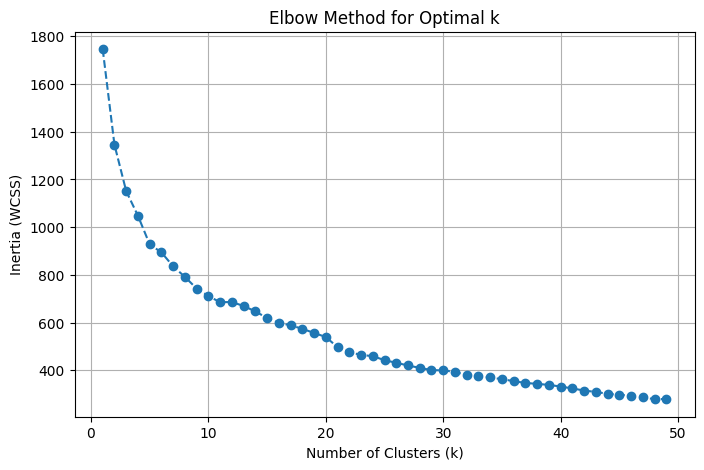

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

We can see that the inertia (within cluster sum of squares drops sharply until k=5, after that, we see a decrease in the rate of inertia dropping, showing us that the our clusters after this value are not significantly improving how cohesive they are. Therefore, lets start with ```k=5

## K Means

In [24]:
# initialize and fit model
optimal_k = 5 
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans_final.fit_predict(ff_norm[financial_cols])

In [36]:
# lets add the cluster labels back to the un normalized and normalized data
ff_norm['cluster_label'] = clusters
ff['cluster_label'] = clusters

## Visualizing with PCA
- the PCA develops the two principle components based on your data variance. PC1 is in the direction of data with most variance, PC2 is in the direction of second most variation perpindicular to the first
- if i remember correctly, i might be able to use the component anazlysis to help try and determine how important features are, based on how they align with the principle components -- look into this

In [27]:
# initialize PCA and fit data
pca = PCA(n_components=2)
pca_features = pca.fit_transform(ff_norm[financial_cols])

In [31]:
# make a df
pca_df = pd.DataFrame(
    data = pca_features, 
    columns = ['pc1', 'pc2']
)
pca_df['cluster'] = clusters

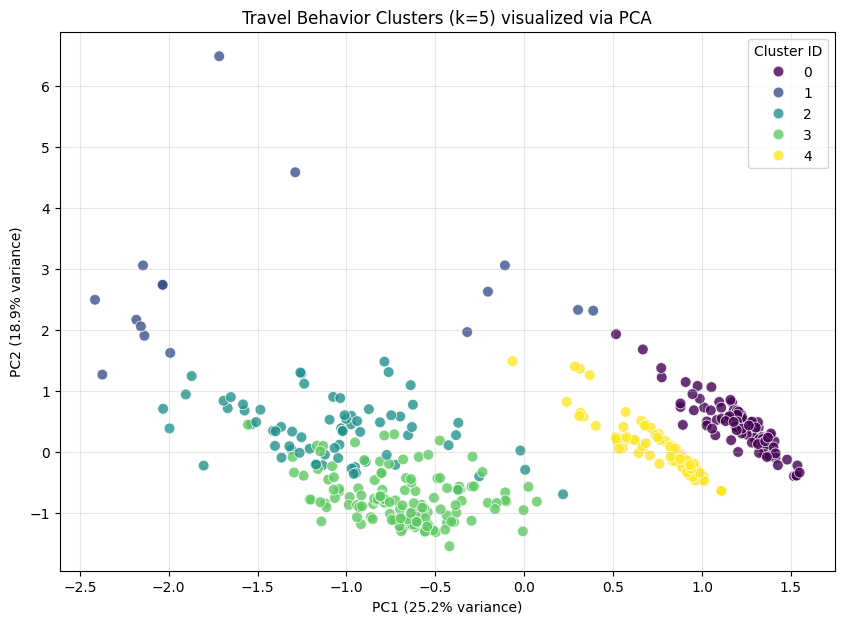

In [35]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='pc1', 
    y='pc2', 
    hue='cluster', 
    data=pca_df, 
    palette='viridis', 
    s=60, 
    alpha=0.8
)

plt.title('Travel Behavior Clusters (k=5) visualized via PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

first thoughts:
- 2 very distinct clusters appearing
- 1 outlier looking cluster. Looks like days i might have done something very different than other days, but not exaclty falling along a specific pattern. maybe high spending?
- 2 clusters that have some overlap in the middle. The likely have some common patterns in their features. Might not be distinct enough to keep as seperate clusters.
- It almost looks like we might have a 3rd component with high variance on that diagonal

### 3D PCA 

In [37]:
# initialize PCA and fit data
pca_3d = PCA(n_components=3)
pca_features_3d = pca_3d.fit_transform(ff_norm[financial_cols])



In [42]:
# make a df
pca_df_3d = pd.DataFrame(
    data = pca_features_3d, 
    columns = ['pc1', 'pc2', 'pc3']
)
pca_df_3d['cluster'] = clusters.astype(str)

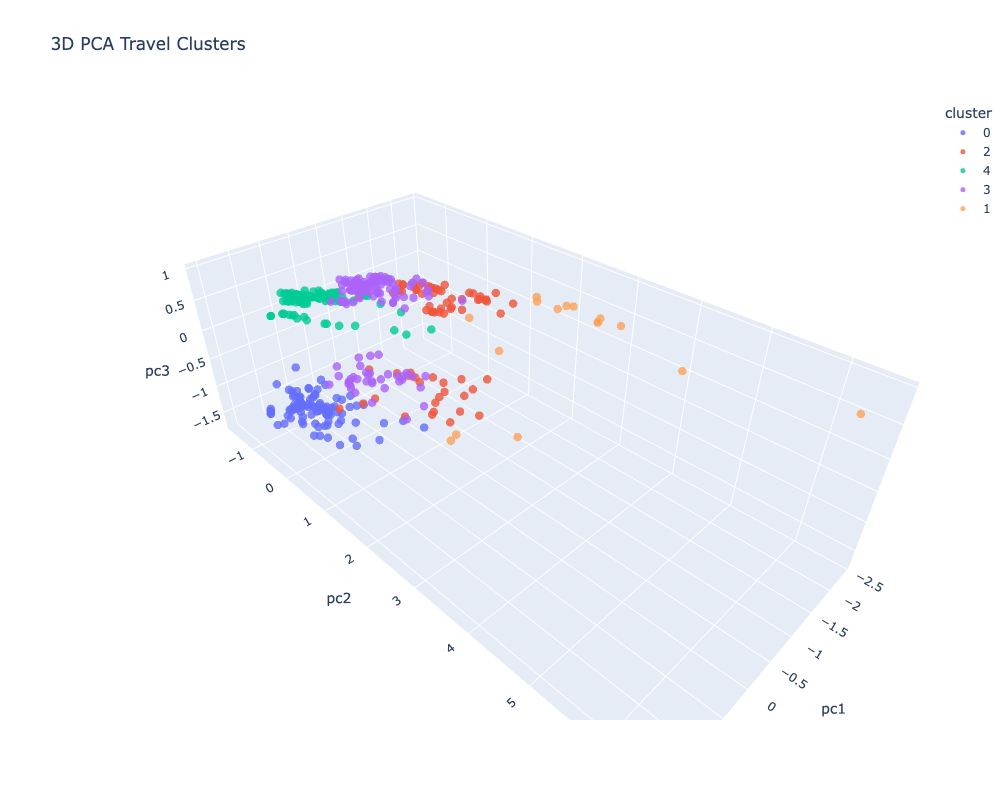

In [43]:
fig = px.scatter_3d(
    pca_df_3d, 
    x='pc1', 
    y='pc2', 
    z='pc3',
    color='cluster',
    title='3D PCA Travel Clusters',
    labels={
        'PC1': f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
        'PC2': f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
        'PC3': f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})'
    },
    opacity=0.8,
    height=800,
    width=800
)

# Adjust marker size for better visibility
fig.update_traces(marker=dict(size=5))
fig.show()

- outlier cluster staying weird
- distinct clusters remaining distinct along PC3
- two lightly overlapping clusters are not seperated when including PC3, but rather each cluster has ~1/3 of their days seperated along the PC3 the same amount as the other. It almost looks like these two clusters, could be split into 2 different clusters along PC3
    - This looks like a binary toggle that is a global condition affecting a lot of my trip
- PC3 has a 12.4% variation within the component, which is pretty high. Its worth using for visualization

In [47]:
# what features are contributing the most to PC3?
loadings = pd.DataFrame(
    pca_3d.components_.T, 
    columns=['pc1', 'pc2', 'pc3'], 
    index=ff_norm[financial_cols].columns
)

# Look for the highest absolute values in the PC3 column
loadings['pc3'].sort_values(ascending=False).head()

primary_transport_0    0.585498
activity_type_0        0.173980
prob_dorm              0.169294
activity_type_1        0.046246
budget_utilization     0.045286
Name: pc3, dtype: float64

**primary_transport_0**: is a 1 when i used no transport. basically means its splitting on if i had a day with transport or no. This is the main focus. PC3 has become a stationary vs. mobile axis

### Dive into the data

In [50]:
ff.head()

,date,total_expense,transactions_per_day,budget_utilization,category_count,baseline_cost,adventure_cost,material_purchases,experience_ratio,prob_camping,...,primary_transport,night_travel_ratio,hours_per_transit,activity_time,is_activity,is_tour,activity_count,novelty_flag,activity_type,cluster_label
0,2024-07-01,0.943631,0.307692,0.778333,0.428571,0.976575,0.000000,0.0,0.000000,0.036296,...,3.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2024-07-02,0.952551,0.307692,1.024000,0.571429,0.965407,0.941165,0.0,0.526367,0.009779,...,2.0,0.0,2.0,4.0,0.0,1.0,1.0,1.0,2.0,2
2,2024-07-03,0.930389,0.461538,0.542500,0.571429,0.962668,0.829922,0.0,0.151459,0.023796,...,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2024-07-04,0.923693,0.307692,0.460167,0.285714,0.971351,0.000000,0.0,0.000000,0.023796,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
4,2024-07-05,0.917756,0.307692,0.401167,0.285714,0.966516,0.000000,0.0,0.000000,0.023796,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


#### Cluster 1: Outlier Cluster

#### Cluster 2: Lightly overlapping cluster

#### Cluster 3: Lightly overlapping cluster

#### Cluster 0: Distinct cluster

#### Cluster 4: Distinct cluster